Sources:
(https://www.rdkit.org/docs/source/rdkit.Chem.rdMolDescriptors.html)
https://www.rdkit.org/docs/GettingStartedInPython.html#substructure-searches

In [62]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, PandasTools
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rdkit.Chem import rdMolDescriptors

In [23]:
linker_data = pd.read_csv('data/linkers.csv', encoding = 'latin1')
linker_trunc = linker_data.iloc[:800]

In [24]:
batches = pd.DataFrame()
for i in range(0,701, 100):
    batch = pd.read_pickle(f"data/adc_data/adc_batch_{i}.pkl")
    batches = pd.concat([batches, batch])

In [25]:
batches = batches.reset_index()
linker_trunc  = linker_trunc.reset_index()
merged_linker = linker_trunc.merge(batches, left_index=True, right_index=True)
merged_linker['smiles_x'].equals(merged_linker['smiles_y'])

True

In [26]:
linker = merged_linker.dropna(subset=['linker_name'])
linker.rename(columns={"smiles_x" : "smiles"}, inplace=True)

/var/folders/rd/v2bddbb535d5nx97qxbb4n9c0000gn/T/ipykernel_69220/3336382226.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  linker.rename(columns={"smiles_x" : "smiles"}, inplace=True)


In [27]:
#convert SMILES to RDKit, remove invalid entries
linker = linker.assign(molecule = linker['smiles'].apply(Chem.MolFromSmiles)).query('molecule.notnull()')
#create canonical smiles so that all versions of same molecule maps to the same SMILES string
linker['smiles'] = linker['molecule'].apply(Chem.MolToSmiles)
#remove duplicate values

#use one hot encoding -- needed for later
linker_encoder = OneHotEncoder(sparse_output = False)
encoded_linker = linker_encoder.fit_transform(linker[['source']])
encoded = pd.DataFrame(encoded_linker, columns = linker_encoder.get_feature_names_out(['source']))
#join both the linker and OHE data
linker = pd.concat([linker.reset_index(drop = True), encoded.reset_index(drop = True)], axis = 1)
linker.head()

,index_x,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,...,index_y,smiles_y,linker_name,adc_name,drug_status,indication,antibody_name,payload_name,molecule,source_train
0,0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,...,0,CC(=O)N[C@@H](CC1=CC=CC=C1)C(=O)N[C@@H](CCCCNC...,Cleavable disulfide,DCLL9718S,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x14e9c9fc0>,1.0
1,2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,...,2,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,Cleavable disulfide,HuN901-CC-1065,Clinical candidate,Small cell lung cancer,Lorvotuzumab,Rachelmycin,<rdkit.Chem.rdchem.Mol object at 0x14e9ca030>,1.0
2,3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,...,3,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,Cleavable disulfide,DCLL9718S,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x14e9c8f20>,1.0
3,4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,...,4,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,Cleavable disulfide,DCLL9718S,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x14e9c8f90>,1.0
4,5,5,5,5,Val-cit-PAB-OH,CC(C)[C@H](N)C(=O)N[C@@H](CCCNC(N)=O)C(=O)Nc1c...,2.890504,159.57,0.315935,0.0340,...,5,CC(C)[C@@H](C(=O)N[C@@H](CCCNC(=O)N)C(=O)NC1=C...,Cleavable disulfide,HuN901-CC-1065,Clinical candidate,Small cell lung cancer,Lorvotuzumab,Rachelmycin,<rdkit.Chem.rdchem.Mol object at 0x14e9c9070>,1.0


In [28]:
#get the SMARTS syntax for hydrophilic functional groups -- going to try to find more that are important
hg = {'hydroxyl': Chem.MolFromSmarts('[OX2;H]'), 'carboxyl' : Chem.MolFromSmarts('C(=O)[OX2H]'), 'amino': Chem.MolFromSmarts('[NX3;H2;!$(NC=O)]'), 'phosphate': Chem.MolFromSmarts('[PX4;!$(P(=O)(O)(O))]')}

def smarts(func_group):
    
    valid_smarts = {}
    for name, molecule in func_group.items():
        if molecule:
            valid_smarts[name] = molecule
        else:
            print(f'Invalid')
        
    return valid_smarts

#use SMARTS on a molecule
def run_smarts (molecule, pattern):

    return {name: int(molecule.HasSubstructMatch(p)) for name, p in pattern.items()}

#apply to all
hydrophilic_groups = linker['molecule'].apply(lambda mol: run_smarts(mol, hg))

#create DataFrame
hydrophilic = pd.DataFrame(list(hydrophilic_groups), index = linker.index)
#when this re-runs, duplicate columns are made.. this will prevent those from popping up
linker = linker.drop(columns = ['hydroxyl', 'carboxyl', 'amino', 'phosphate'], errors = 'ignore')
#join both dataframes
linker = linker.join(hydrophilic)

linker.head()


,index_x,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,...,drug_status,indication,antibody_name,payload_name,molecule,source_train,hydroxyl,carboxyl,amino,phosphate
0,0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,...,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x14e9c9fc0>,1.0,0,0,0,0
1,2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,...,Clinical candidate,Small cell lung cancer,Lorvotuzumab,Rachelmycin,<rdkit.Chem.rdchem.Mol object at 0x14e9ca030>,1.0,1,0,0,0
2,3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,...,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x14e9c8f20>,1.0,0,0,0,0
3,4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,...,Investigative,Acute myeloid leukaemia,MCLL0517A,PBD dimer,<rdkit.Chem.rdchem.Mol object at 0x14e9c8f90>,1.0,0,0,0,0
4,5,5,5,5,Val-cit-PAB-OH,CC(C)[C@H](N)C(=O)N[C@@H](CCCNC(N)=O)C(=O)Nc1c...,2.890504,159.57,0.315935,0.0340,...,Clinical candidate,Small cell lung cancer,Lorvotuzumab,Rachelmycin,<rdkit.Chem.rdchem.Mol object at 0x14e9c9070>,1.0,1,0,1,0


In [29]:
linker['total_rings'] = linker['molecule'].apply(lambda mol: mol.GetRingInfo().NumRings())
linker['aromatic_rings'] = linker['molecule'].apply(lambda mol: Descriptors.NumAromaticRings(mol))
linker['aliphatic_rings'] = linker['molecule'].apply(lambda mol: Descriptors.NumAliphaticRings(mol))

In [30]:
linker.to_pickle("data/adc_data.pkl")

In [31]:
# Get general stats on relevant features:
linker[['calc_SA_score', 'TPSA', 'QED', 'LogP', 'Molecular Weight']].describe()

,calc_SA_score,TPSA,QED,LogP,Molecular Weight
count,447.000000,447.000000,447.000000,447.000000,447.000000
mean,3.083530,140.971477,0.207665,0.834930,516.046353
std,0.764230,74.608280,0.152933,1.619025,321.939805
min,1.922994,18.460000,0.013470,-3.167200,99.130000
25%,2.581948,84.010000,0.070864,-0.302350,295.365000
50%,2.861059,120.390000,0.167072,0.551600,448.550000
75%,3.367450,185.890000,0.334425,1.504850,656.270000
max,7.707836,451.920000,0.638986,11.399300,2159.630000


#### Feature Description Table
| Feature Name | Meaning | Description |
|:-----|:---:|:-----|
| calc_SA_score | Synthetic Accessibility Score | lower = easier to synthesize in lab, higher = more complex. |
| TPSA | Topological Polar Surface Area | Higher = more polar (hydrophillic) |
| QED | Quantitative Estimate of Drug-likeness | combines multiple molecular properties into single drug-likeness score between 0 and 1. Higher score = more drug-like |
| LogP | Octanol-Water Partition Coefficient | high/positive = hydrophobic, low/negative = hydrophilic |
| Molecular Weight| Sum of atomic weights of all atoms | smaller molecules usually more permeable, larger tend to be less mobile/permeable |

In [32]:
# I consolidated Alex and Sana's feature descriptions into one table from Sana's EDA
# I removed K-Means because I don't think that's a feature descriptor itself, 
# but is a categorical result of feature analysis? Feel free to weigh in on this?
# - Hailey

# Analyzing Current Data

In [33]:
linker.columns

Index(['index_x', 'Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1', 'Product name',
       'smiles', 'calc_SA_score', 'TPSA', 'QED', 'LogP', 'Molecular Weight',
       'K-means', 'scaffold_smiles', 'source', 'index_y', 'smiles_y',
       'linker_name', 'adc_name', 'drug_status', 'indication', 'antibody_name',
       'payload_name', 'molecule', 'source_train', 'hydroxyl', 'carboxyl',
       'amino', 'phosphate', 'total_rings', 'aromatic_rings',
       'aliphatic_rings'],
      dtype='object')

In [34]:
linker['drug_status'].value_counts()

drug_status
Investigative         401
Clinical candidate     45
Phase 2                 1
Name: count, dtype: int64

In [35]:
linker['antibody_name'].value_counts()

antibody_name
Cetuximab                                                           239
MCLL0517A                                                           114
Patritumab                                                           47
Lorvotuzumab                                                         42
Undisclosed                                                           2
J22.9-ISY                                                             1
Rosopatamab                                                           1
Anti HER2 1-alpha-hydroxyvitamin-D5-HER-2 antibody conjugate mAb      1
Name: count, dtype: int64

In [36]:
linker['linker_name'].value_counts()

linker_name
Succinimidyl acetylthiopropionate (SATP)                          239
Cleavable disulfide                                               156
ADC-C1 linker                                                      47
Mal-Val-Ala-PAB                                                     3
Tetraxetan                                                          1
Sulfosuccinimidyl 6-4 azido nitrophenylamido hexanode (SANPAH)      1
Name: count, dtype: int64

In [37]:
linker['payload_name'].value_counts()

payload_name
Puromycin                    239
PBD dimer                    114
ADC-C1 payload                47
Rachelmycin                   42
HDP 30.2115                    3
Y90 (Radioactive isotope)      1
Vitamin D                      1
Name: count, dtype: int64

([0, 1, 2],
 [Text(0, 0, 'Investigative'),
  Text(1, 0, 'Clinical candidate'),
  Text(2, 0, 'Phase 2')])

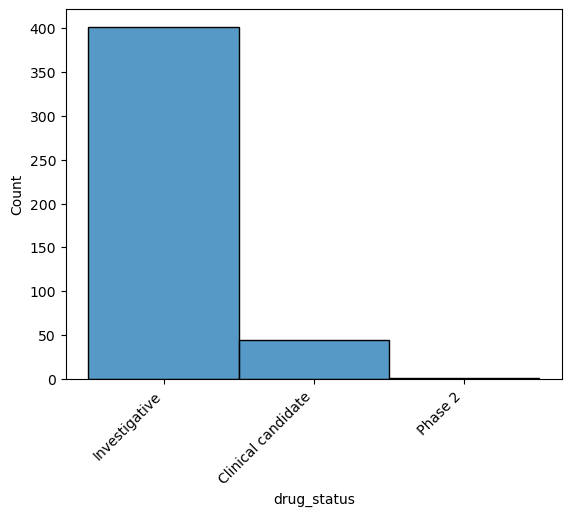

In [38]:
sns.histplot(x=linker['drug_status'])
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'MCLL0517A'),
  Text(1, 0, 'Lorvotuzumab'),
  Text(2, 0, 'Patritumab'),
  Text(3, 0, 'Cetuximab'),
  Text(4, 0, 'Undisclosed'),
  Text(5, 0, 'J22.9-ISY'),
  Text(6, 0, 'Rosopatamab'),
  Text(7, 0, 'Anti HER2 1-alpha-hydroxyvitamin-D5-HER-2 antibody conjugate mAb')])

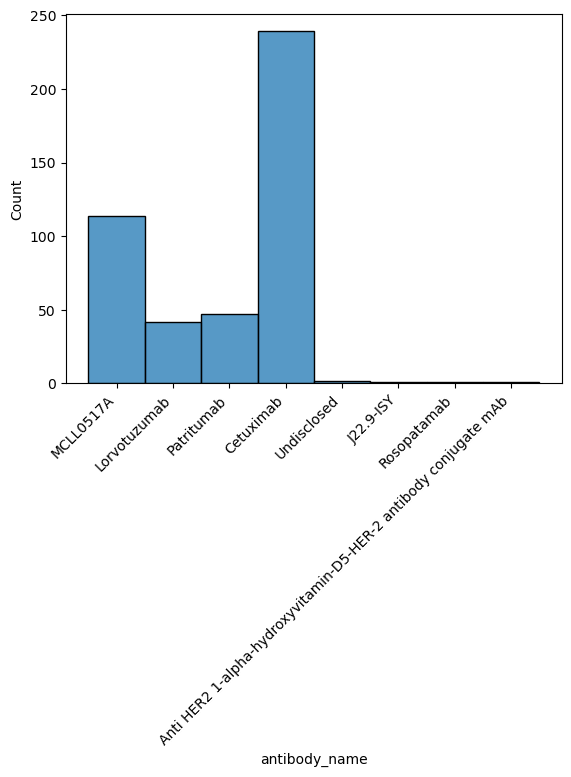

In [39]:
sns.histplot(x=linker['antibody_name'])
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Cleavable disulfide'),
  Text(1, 0, 'ADC-C1 linker'),
  Text(2, 0, 'Succinimidyl acetylthiopropionate (SATP)'),
  Text(3, 0, 'Mal-Val-Ala-PAB'),
  Text(4, 0, 'Tetraxetan'),
  Text(5, 0, 'Sulfosuccinimidyl 6-4 azido nitrophenylamido hexanode (SANPAH)')])

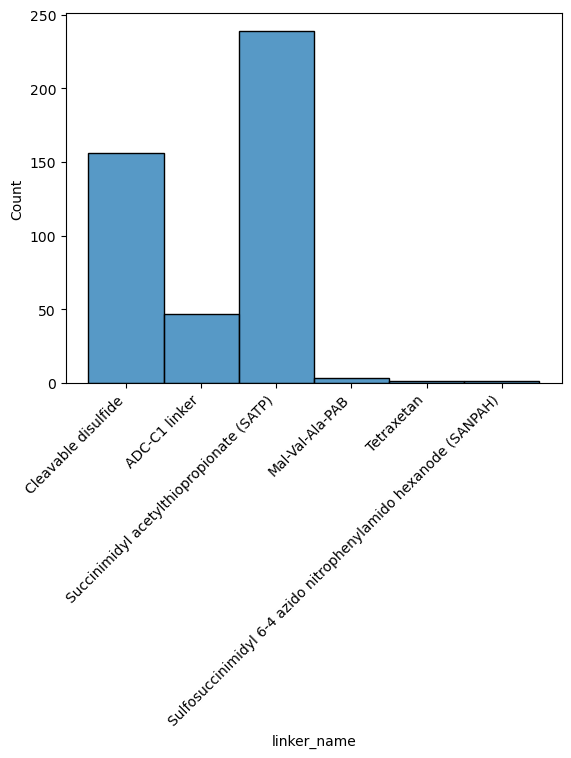

In [40]:
sns.histplot(x=linker['linker_name'])
plt.xticks(rotation=45, ha='right')

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'PBD dimer'),
  Text(1, 0, 'Rachelmycin'),
  Text(2, 0, 'ADC-C1 payload'),
  Text(3, 0, 'Puromycin'),
  Text(4, 0, 'HDP 30.2115'),
  Text(5, 0, 'Y90 (Radioactive isotope)'),
  Text(6, 0, 'Vitamin D')])

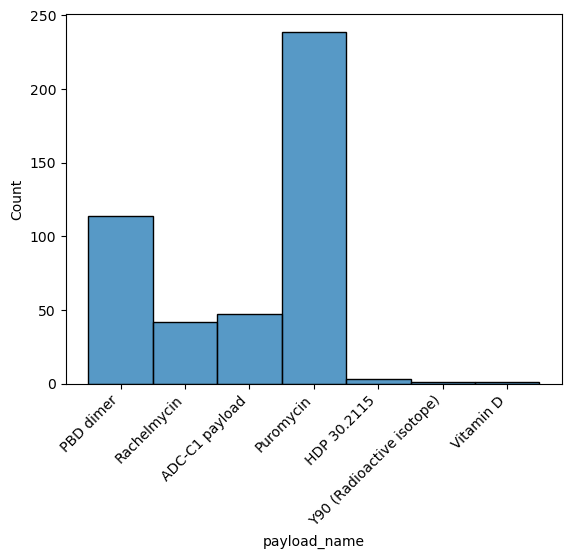

In [41]:
sns.histplot(x=linker['payload_name'])
plt.xticks(rotation=45, ha='right')

In [42]:
linker['K-means'].unique()

array([12,  2,  4,  1,  5,  6,  3,  7, 13, 10,  0,  8, 11])

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'sqrt(LogP)')

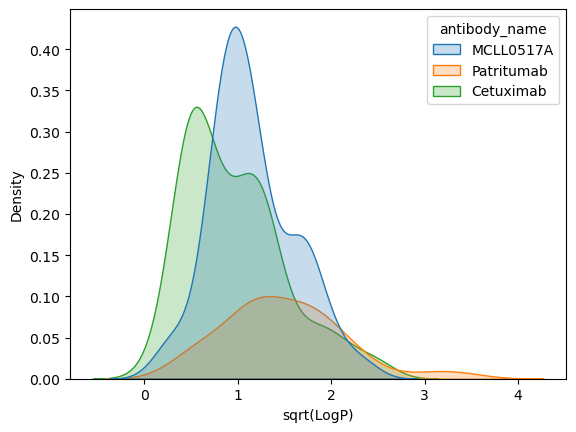

In [43]:
antibody = ['Cetuximab','MCLL0517A','Patritumab']
sns.kdeplot(data=linker[linker['antibody_name'].isin(antibody)], hue='antibody_name', x=np.sqrt(linker['LogP']), fill=True)
plt.xlabel("sqrt(LogP)")

/opt/miniconda3/envs/msse-python/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'sqrt(LogP)')

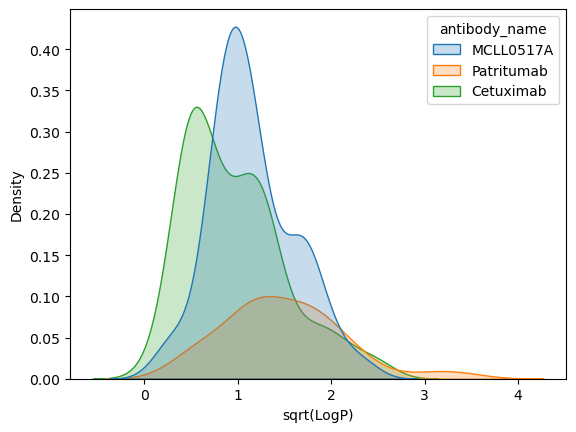

In [44]:
antibody = ['Cetuximab','MCLL0517A','Patritumab']
sns.kdeplot(data=linker[linker['antibody_name'].isin(antibody)], hue='antibody_name', x=np.sqrt(linker['LogP']), fill=True)
plt.xlabel("sqrt(LogP)")

In [66]:
#get number of H donors and acceptors.. important for linker-payload interactions
#get FractionCSP3 and number of rotatable bonds to assess linker flexibility. important in different contexts
#get LabuteASA (approximate surface area) of a molecule, important in regards to solubility

linker['num_h_donors'] = linker['molecule'].apply(Descriptors.NumHDonors)
linker['num_h_acceptors'] = linker['molecule'].apply(Descriptors.NumHAcceptors)
linker['FractionCSP3'] = linker['molecule'].apply(Descriptors.FractionCSP3)
linker['num_rot_bonds'] = linker['molecule'].apply(Descriptors.NumRotatableBonds)
linker['Surface Area'] = linker['molecule'].apply(rdMolDescriptors.CalcLabuteASA)

linker.head()

,index_x,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Product name,smiles,calc_SA_score,TPSA,QED,LogP,...,aromatic_rings,aliphatic_rings,hydrophilicity_score,hydrophilicity_norm,hydrophilicity_class,num_h_donors,num_h_acceptors,FractionCSP3,num_rot_bonds,Surface Area
0,0,0,0,0,(Ac)Phe-Lys(Alloc)-PABC-PNP,C=CCOC(=O)NCCCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(...,3.508295,204.30,0.036588,4.5636,...,3,0,0,0.000000,hydrophobic,4,10,0.285714,18,288.060675
1,2,2,2,2,Fmoc-Val-Cit-PAB,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.338596,171.88,0.163403,3.6140,...,3,1,2,0.003324,hydrophobic,6,6,0.333333,13,256.107099
2,3,3,3,3,Fmoc-Val-Cit-PAB-PNP,CC(C)[C@H](NC(=O)OCC1c2ccccc2-c2ccccc21)C(=O)N...,3.753739,230.32,0.030495,5.7455,...,4,1,0,0.000000,hydrophobic,5,10,0.275000,16,321.776490
3,4,4,4,4,Mc-Val-Cit-PABC-PNP,CC(C)[C@H](NC(=O)CCCCCN1C(=O)C=CC1=O)C(=O)N[C@...,3.796268,258.47,0.032958,2.8084,...,2,1,0,0.000000,hydrophobic,5,11,0.400000,20,304.496626
4,5,5,5,5,Val-cit-PAB-OH,CC(C)[C@H](N)C(=O)N[C@@H](CCCNC(N)=O)C(=O)Nc1c...,2.890504,159.57,0.315935,0.0340,...,1,0,3,0.007906,moderate,6,5,0.500000,10,158.418876


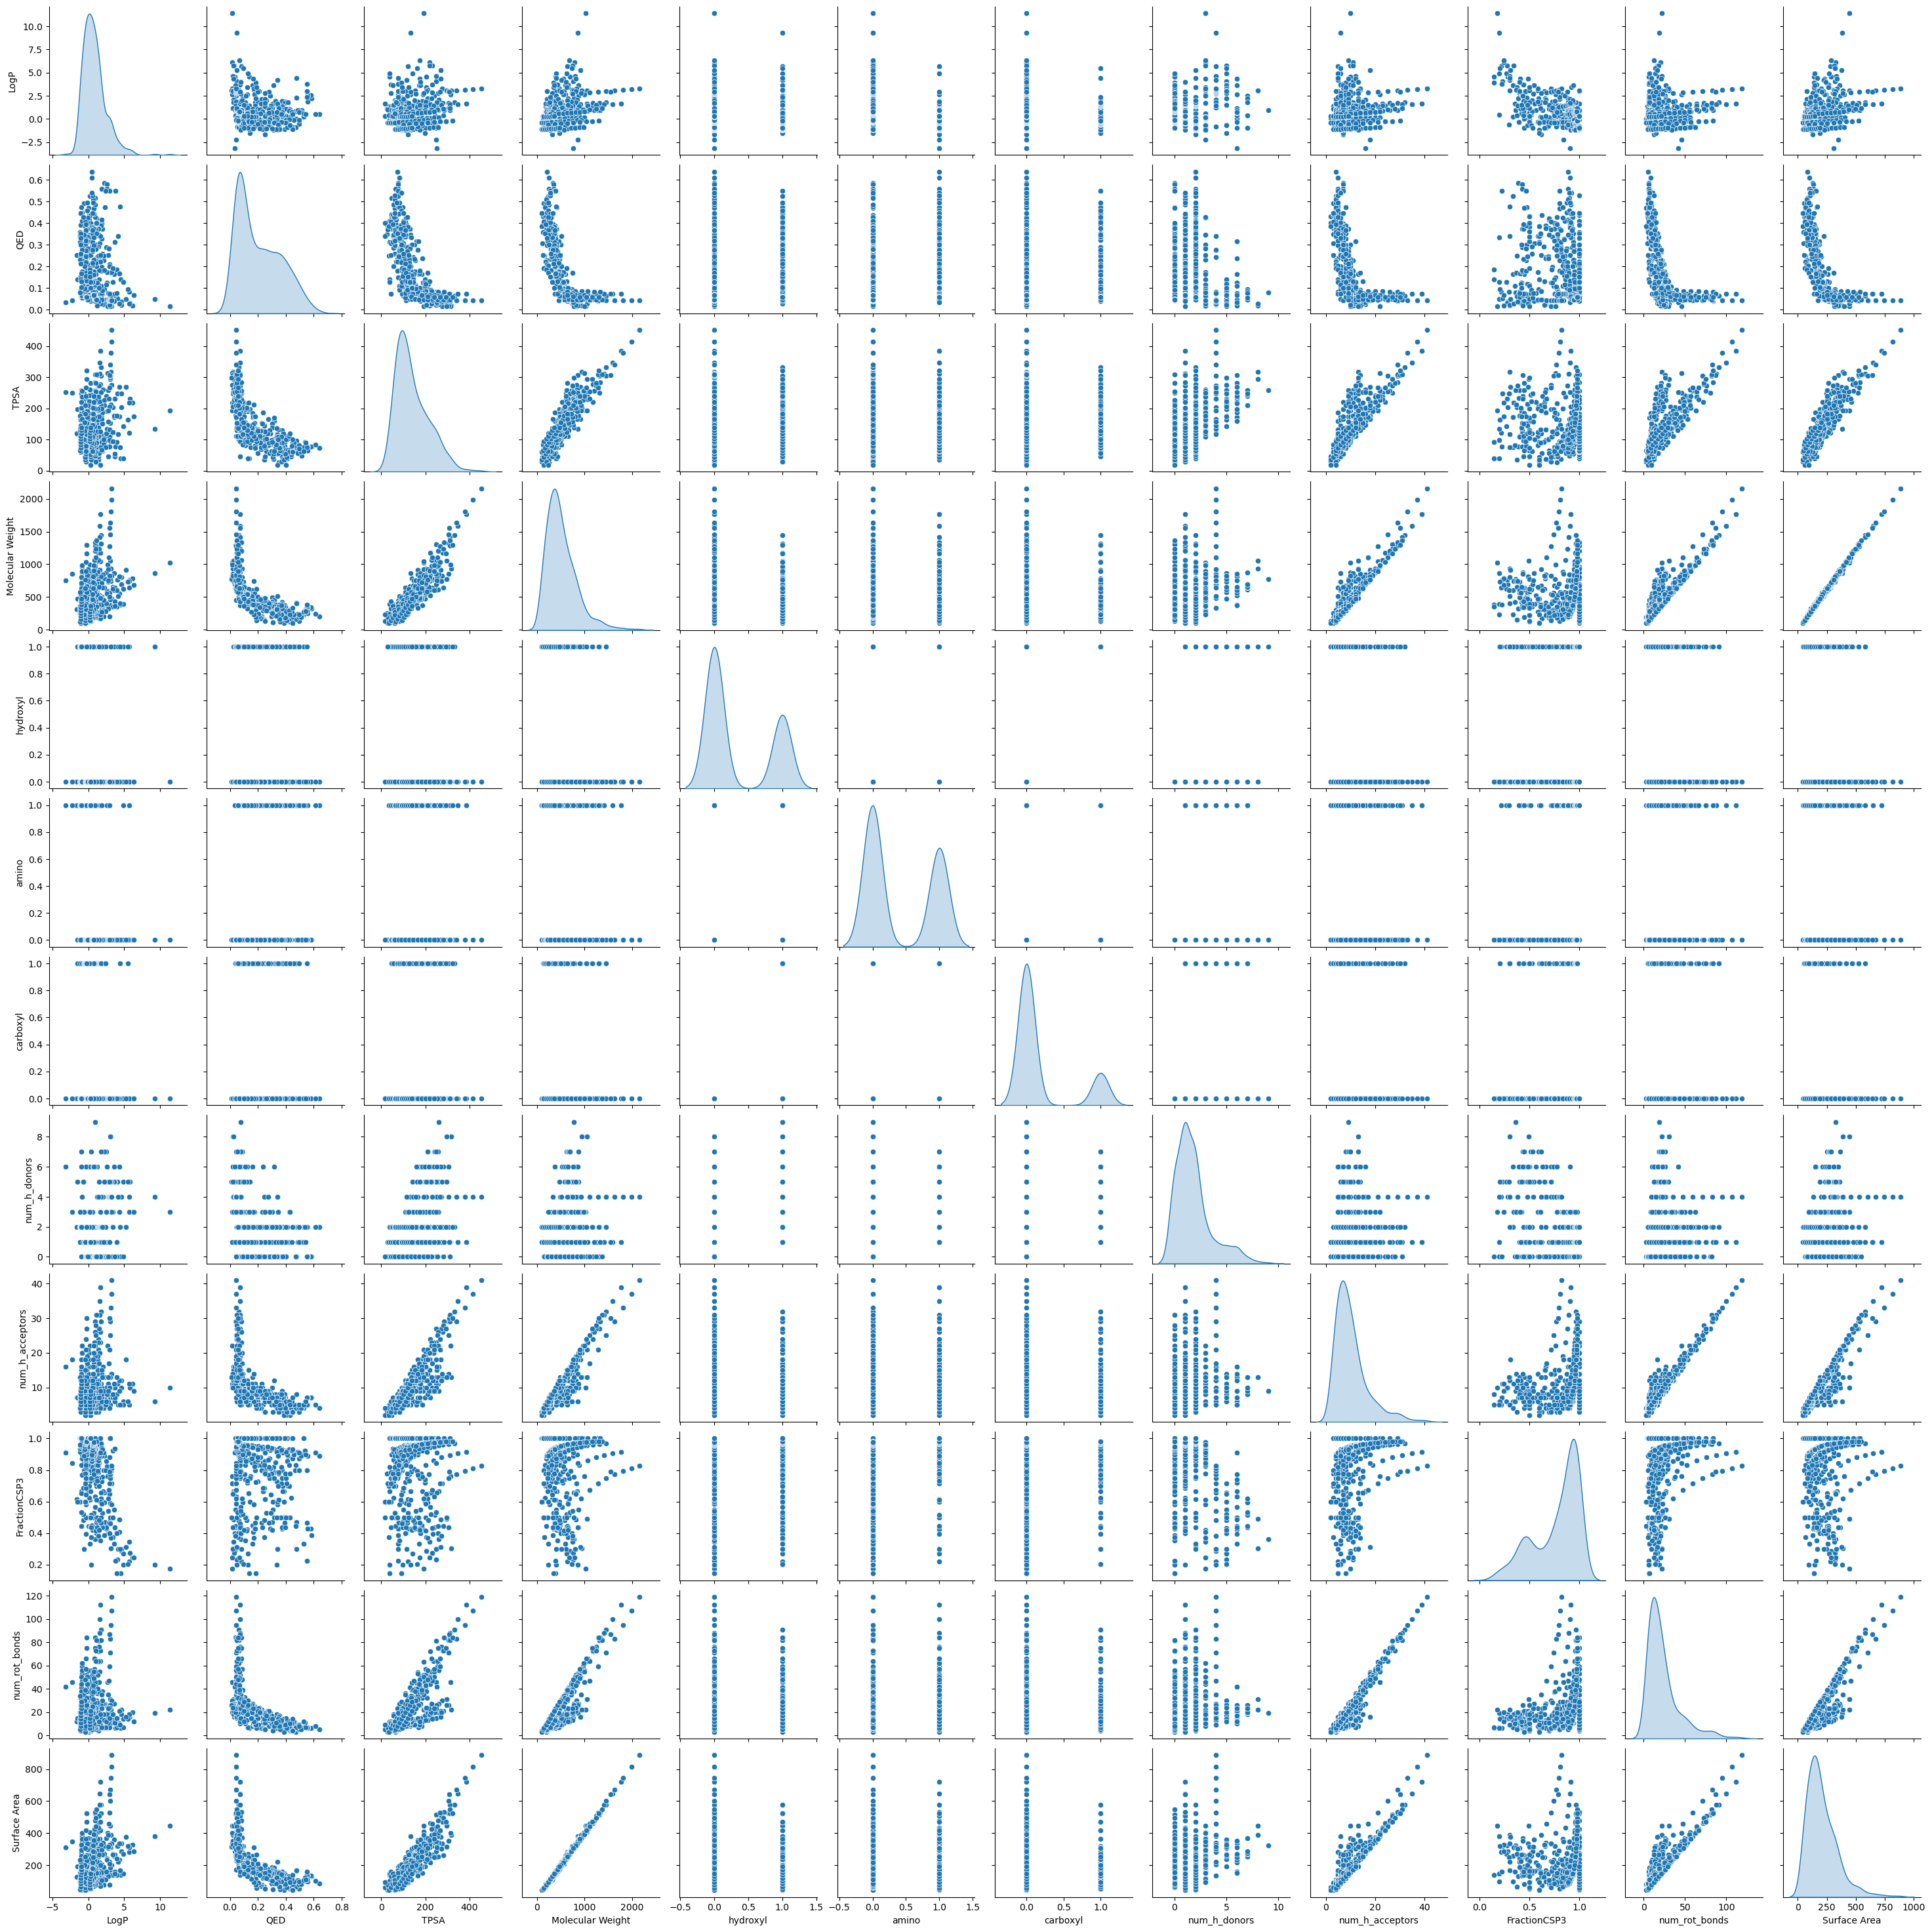

In [65]:
#pair plot to visualize relevant feature relationships (exclude phosphate counts)
sns.pairplot(linker[['LogP', 'QED', 'TPSA', 'Molecular Weight', 
                     'hydroxyl', 'amino', 'carboxyl', 'num_h_donors',
                     'num_h_acceptors', 'FractionCSP3', 'num_rot_bonds', 'Surface Area']], diag_kind='kde')
plt.show()

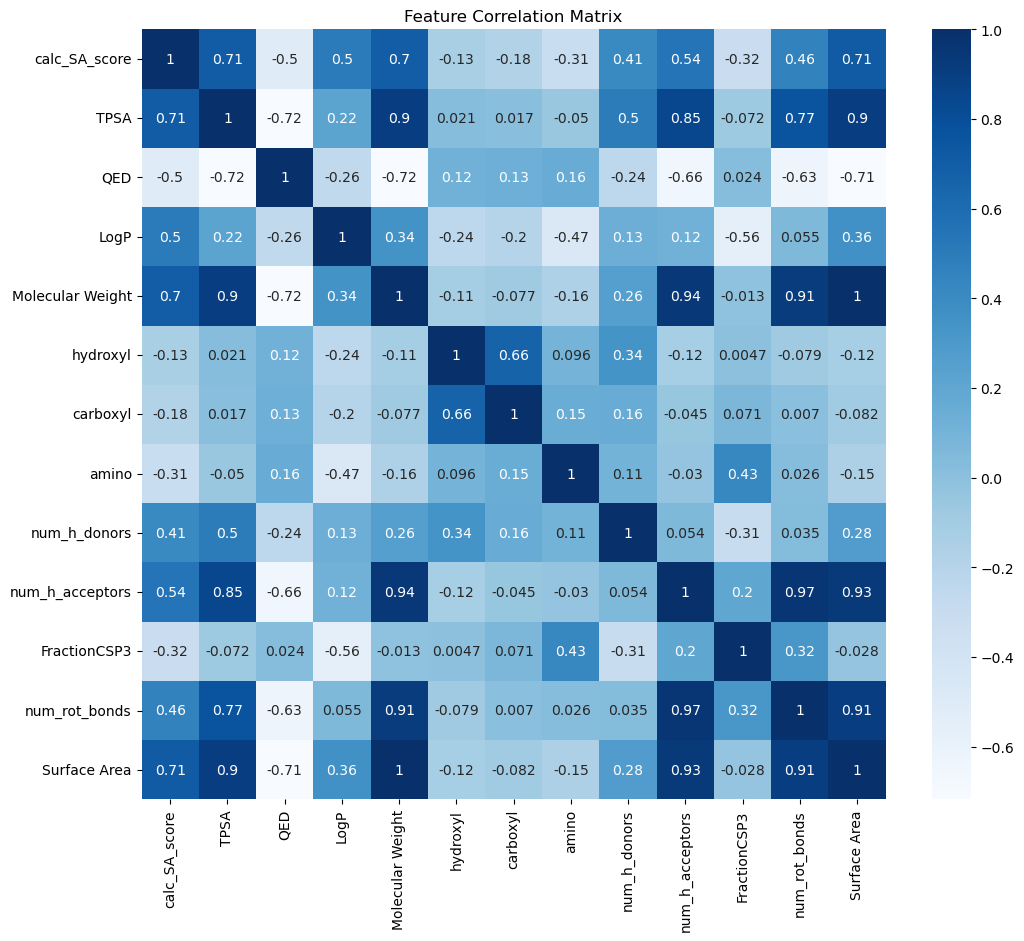

In [68]:
# Plot correlation matrix, exclude phosphate count 

plt.figure(figsize=(12,10))
sns.heatmap(linker[['calc_SA_score', 'TPSA', 'QED', 'LogP', 
                    'Molecular Weight', 'hydroxyl', 
                    'carboxyl', 'amino', 'num_h_donors', 
                    'num_h_acceptors', 'FractionCSP3', 'num_rot_bonds', 
                    'Surface Area']].corr(),
            annot=True, cmap='Blues') #excluding phosphate count since there are 0 everywhere
plt.title("Feature Correlation Matrix")
plt.show()

**Strong Positive Correlations:**
TPSA vs. MW,
TPSA vs. h_acceptors,
h_acceptors vs. MW,
num_rot_bonds vs. TPSA,
num_rot_bonds vs. h_acceptors,
num_rot_bonds vs. SA,
num_rot_bonds vs. MW,
SA vs. TPSA,
SA vs. MW,
SA vs. h_acceptors

**Medium Positive Correlations:**
carboxyl_count vs. hydroxyl_count,

**Moderate Negative Correlations:**
QED vs. TPSA,
num_h_acceptors vs. QED,
QED vs. MW,
num_rot_bonds vs. QED,
SA vs. QED

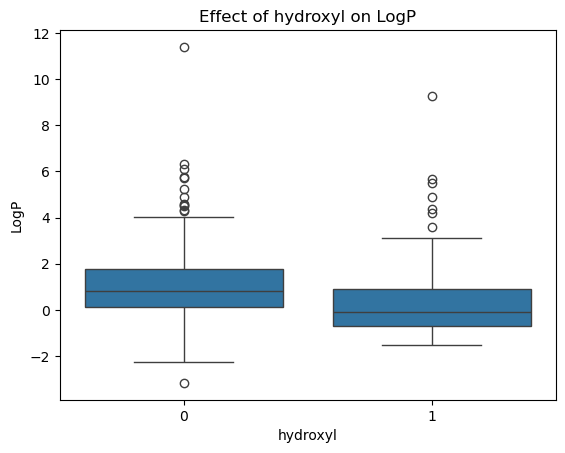

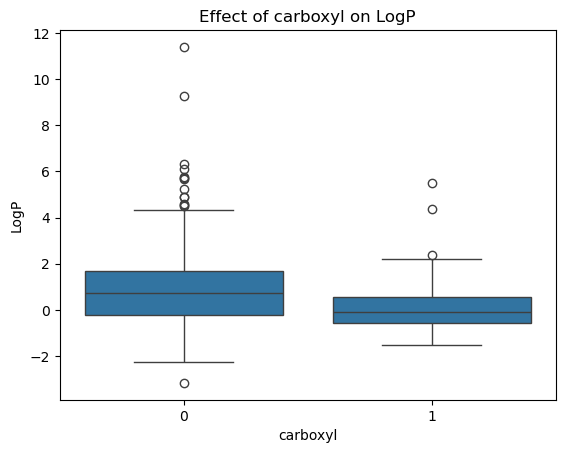

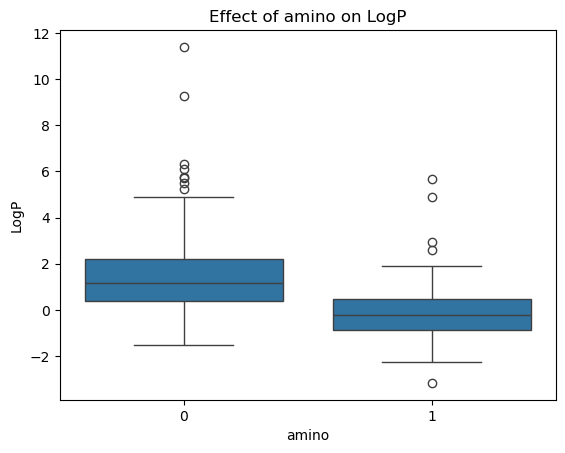

In [48]:
# Visualize effect of functional group counts on LogP (measure of hydrophilicity)
for group in ['hydroxyl', 'carboxyl', 'amino']:
    sns.boxplot(data=linker, x=group, y='LogP')
    plt.title(f'Effect of {group} on LogP')
    plt.show()

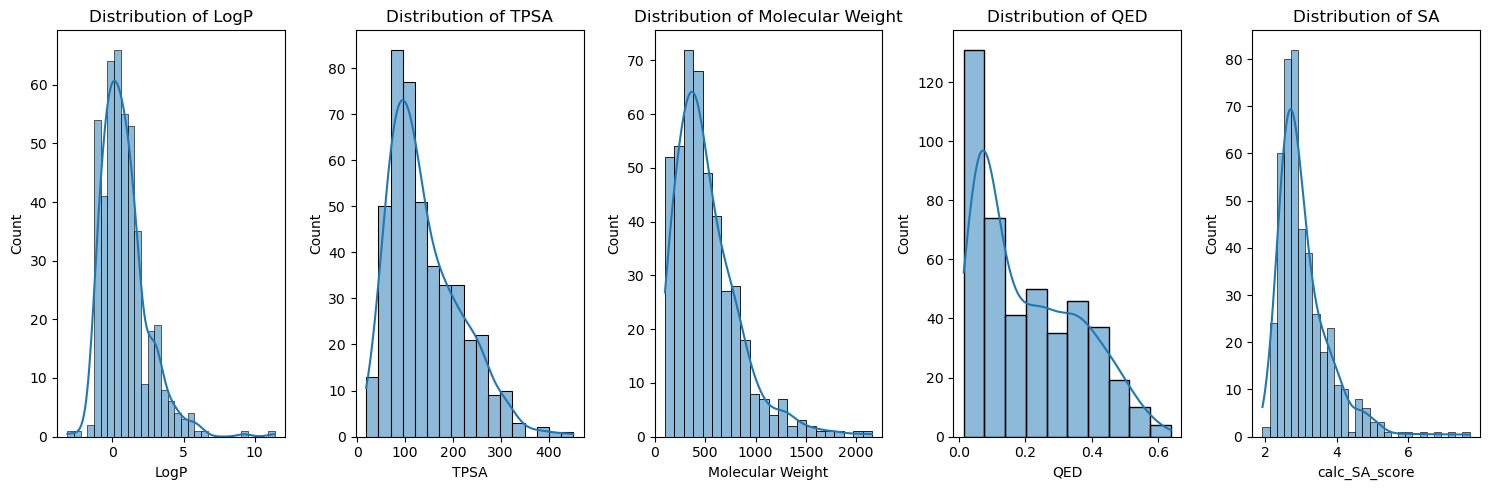

In [49]:
# Distribution of features in our data set
fig, axs = plt.subplots(1, 5, figsize=(15,5))
sns.histplot(linker['LogP'], kde=True, ax=axs[0])
axs[0].set_title('Distribution of LogP')

sns.histplot(linker['TPSA'], kde=True, ax=axs[1])
axs[1].set_title('Distribution of TPSA')

sns.histplot(linker['Molecular Weight'], kde=True, ax=axs[2])
axs[2].set_title('Distribution of Molecular Weight')

sns.histplot(linker['QED'], kde=True, ax=axs[3])
axs[3].set_title('Distribution of QED')

sns.histplot(linker['calc_SA_score'], kde=True, ax=axs[4])
axs[4].set_title('Distribution of SA')

plt.tight_layout()
plt.show()

Functional Groups ranked by hydrophilicity (expected):

Phosphate -> Carboxyl -> Hydroxyl -> Amino

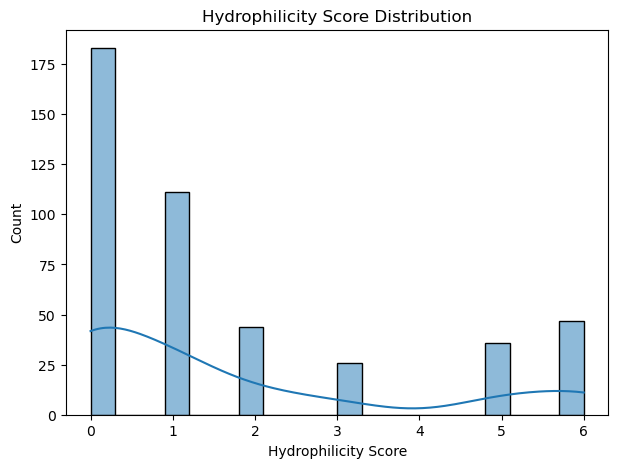

In [51]:
# Generate "Hydrophilicity Score" for our linkers based on functional group
    # add weight to each functional group based on hydrophilicity (higher weight = more hydrophilic)
linker['hydrophilicity_score'] = (
    4 * linker['phosphate'] +
    3 * linker['carboxyl'] +
    2 * linker['hydroxyl'] +
    1 * linker['amino']
)
linker['hydrophilicity_norm'] = linker['hydrophilicity_score'] / linker['Molecular Weight'] # Normalize by molecule size to avoid distortion of data

plt.figure(figsize=(7,5))
sns.histplot(linker['hydrophilicity_score'], bins=20, kde=True)
plt.title('Hydrophilicity Score Distribution')
plt.xlabel('Hydrophilicity Score')
plt.show()

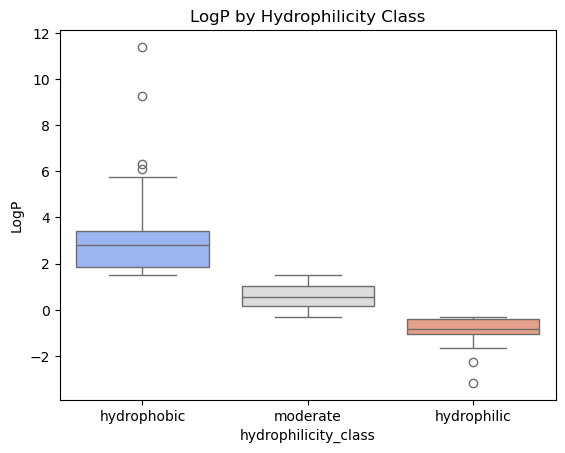

In [52]:
# Define hydrophilicity thresholds directly from LogP
low_thr = linker['LogP'].quantile(0.25)   # 25th percentile
high_thr = linker['LogP'].quantile(0.75)  # 75th percentile

# Create a hydrophilicity_class column based on LogP (specific to our dataset)
linker['hydrophilicity_class'] = linker['LogP'].apply(
    lambda x: 'hydrophilic' if x < low_thr else
              'hydrophobic' if x > high_thr else
              'moderate'
)

sns.boxplot(data=linker, x='hydrophilicity_class', y='LogP', hue='hydrophilicity_class', palette='coolwarm', legend = False)
plt.title('LogP by Hydrophilicity Class')
plt.show()

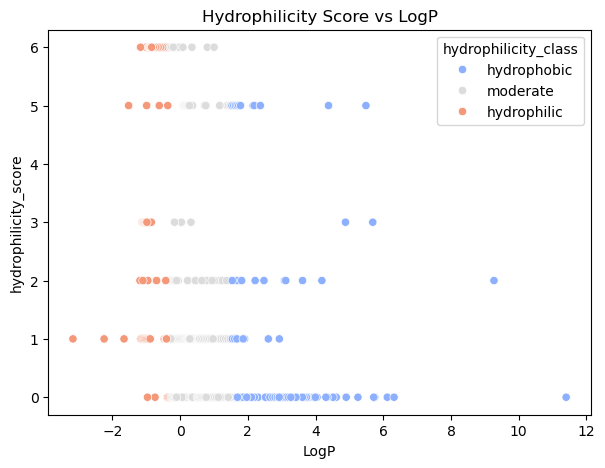

In [53]:
# Visualize separation of hydrophilicity on LogP:

plt.figure(figsize=(7,5))
sns.scatterplot(data=linker, x='LogP', y='hydrophilicity_score',
                hue='hydrophilicity_class', palette='coolwarm')
plt.title('Hydrophilicity Score vs LogP')
plt.show()

In [54]:
# Mean values of our features based on hydrophilicity:

linker.groupby('hydrophilicity_class')[['LogP', 'QED', 'TPSA', 'calc_SA_score']].mean()

,LogP,QED,TPSA,calc_SA_score
hydrophilicity_class,,,,
hydrophilic,-0.785883,0.261742,122.588036,2.701626
hydrophobic,2.988300,0.154791,173.315268,3.790902
moderate,0.567457,0.207060,133.960000,2.920066


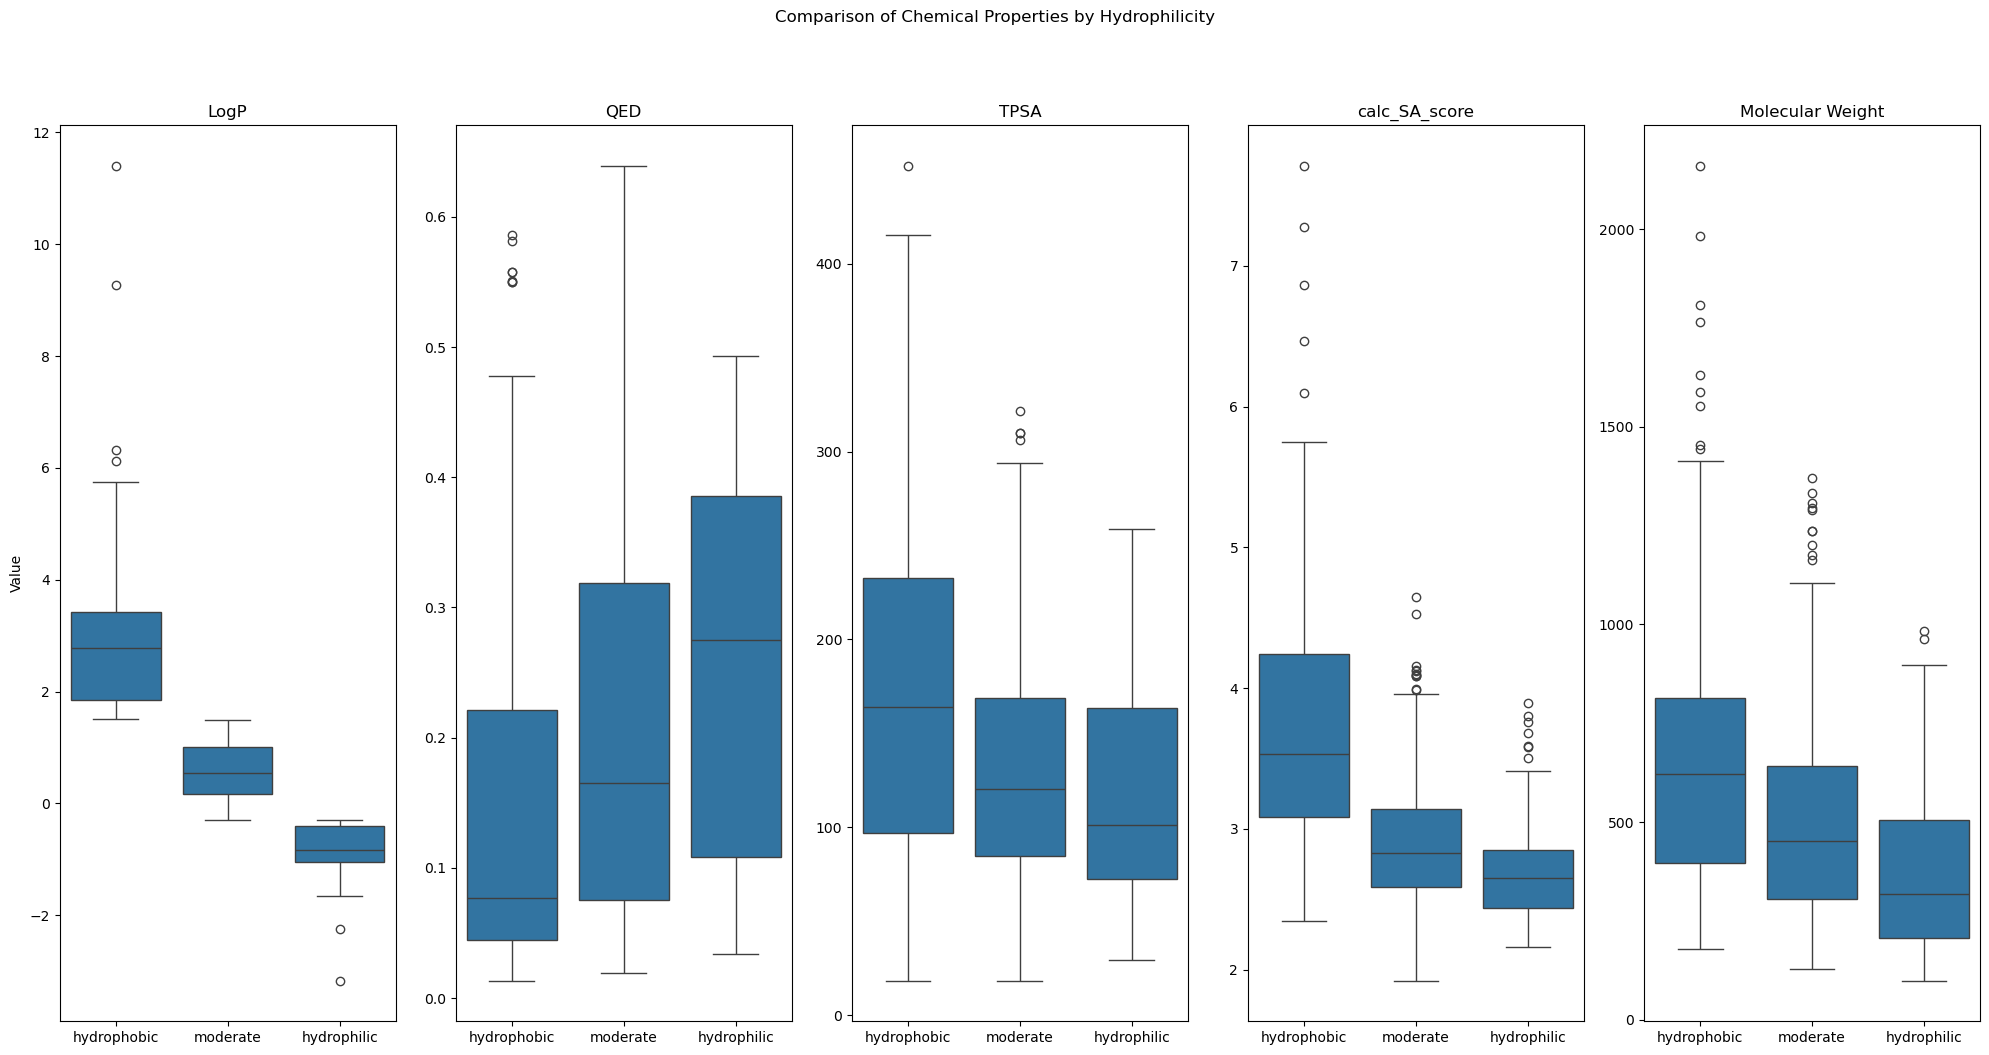

In [55]:
features = ['LogP', 'QED', 'TPSA', 'calc_SA_score', 'Molecular Weight']

plt.figure(figsize=(20, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(data=linker, x='hydrophilicity_class', y=feature,)
    plt.title(feature)
    plt.xlabel('')
    if i == 1:
        plt.ylabel('Value')
    else:
        plt.ylabel('')

plt.suptitle('Comparison of Chemical Properties by Hydrophilicity', y=1.05)
plt.tight_layout()
plt.show()

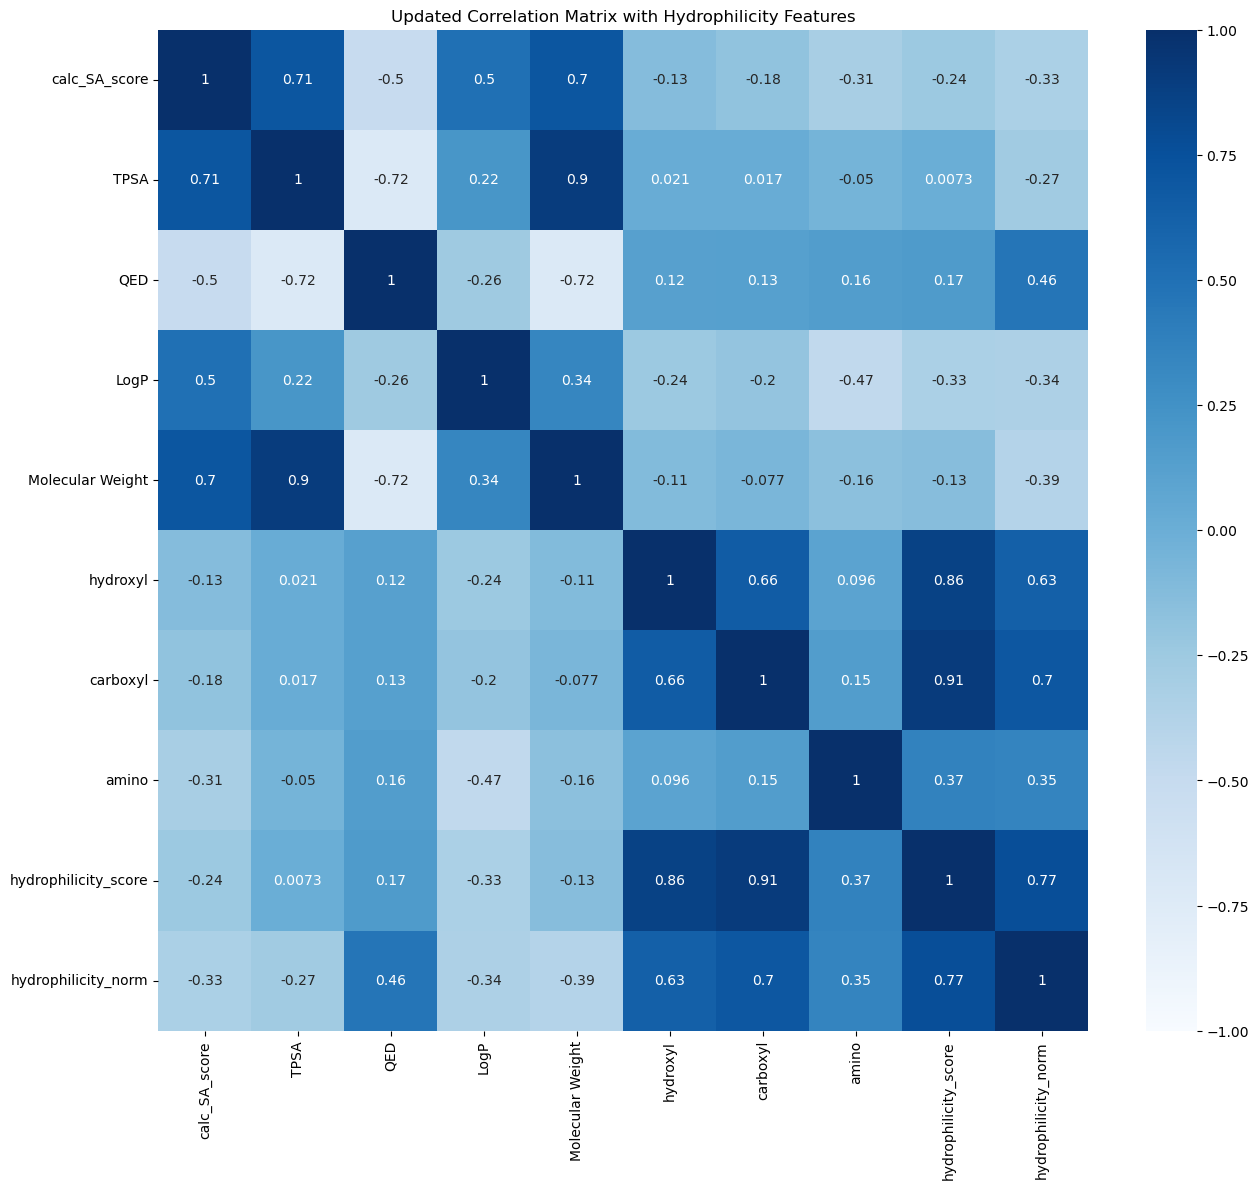

In [57]:
# Updated correlation matrix with hydrophilicity class and score added:

corr_features = [
    'calc_SA_score', 'TPSA', 'QED', 'LogP', 'Molecular Weight',
    'hydroxyl', 'carboxyl', 'amino',
    'hydrophilicity_score', 'hydrophilicity_norm'
]

plt.figure(figsize=(15,13))
sns.heatmap(linker[corr_features].corr(), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Updated Correlation Matrix with Hydrophilicity Features')
plt.show()

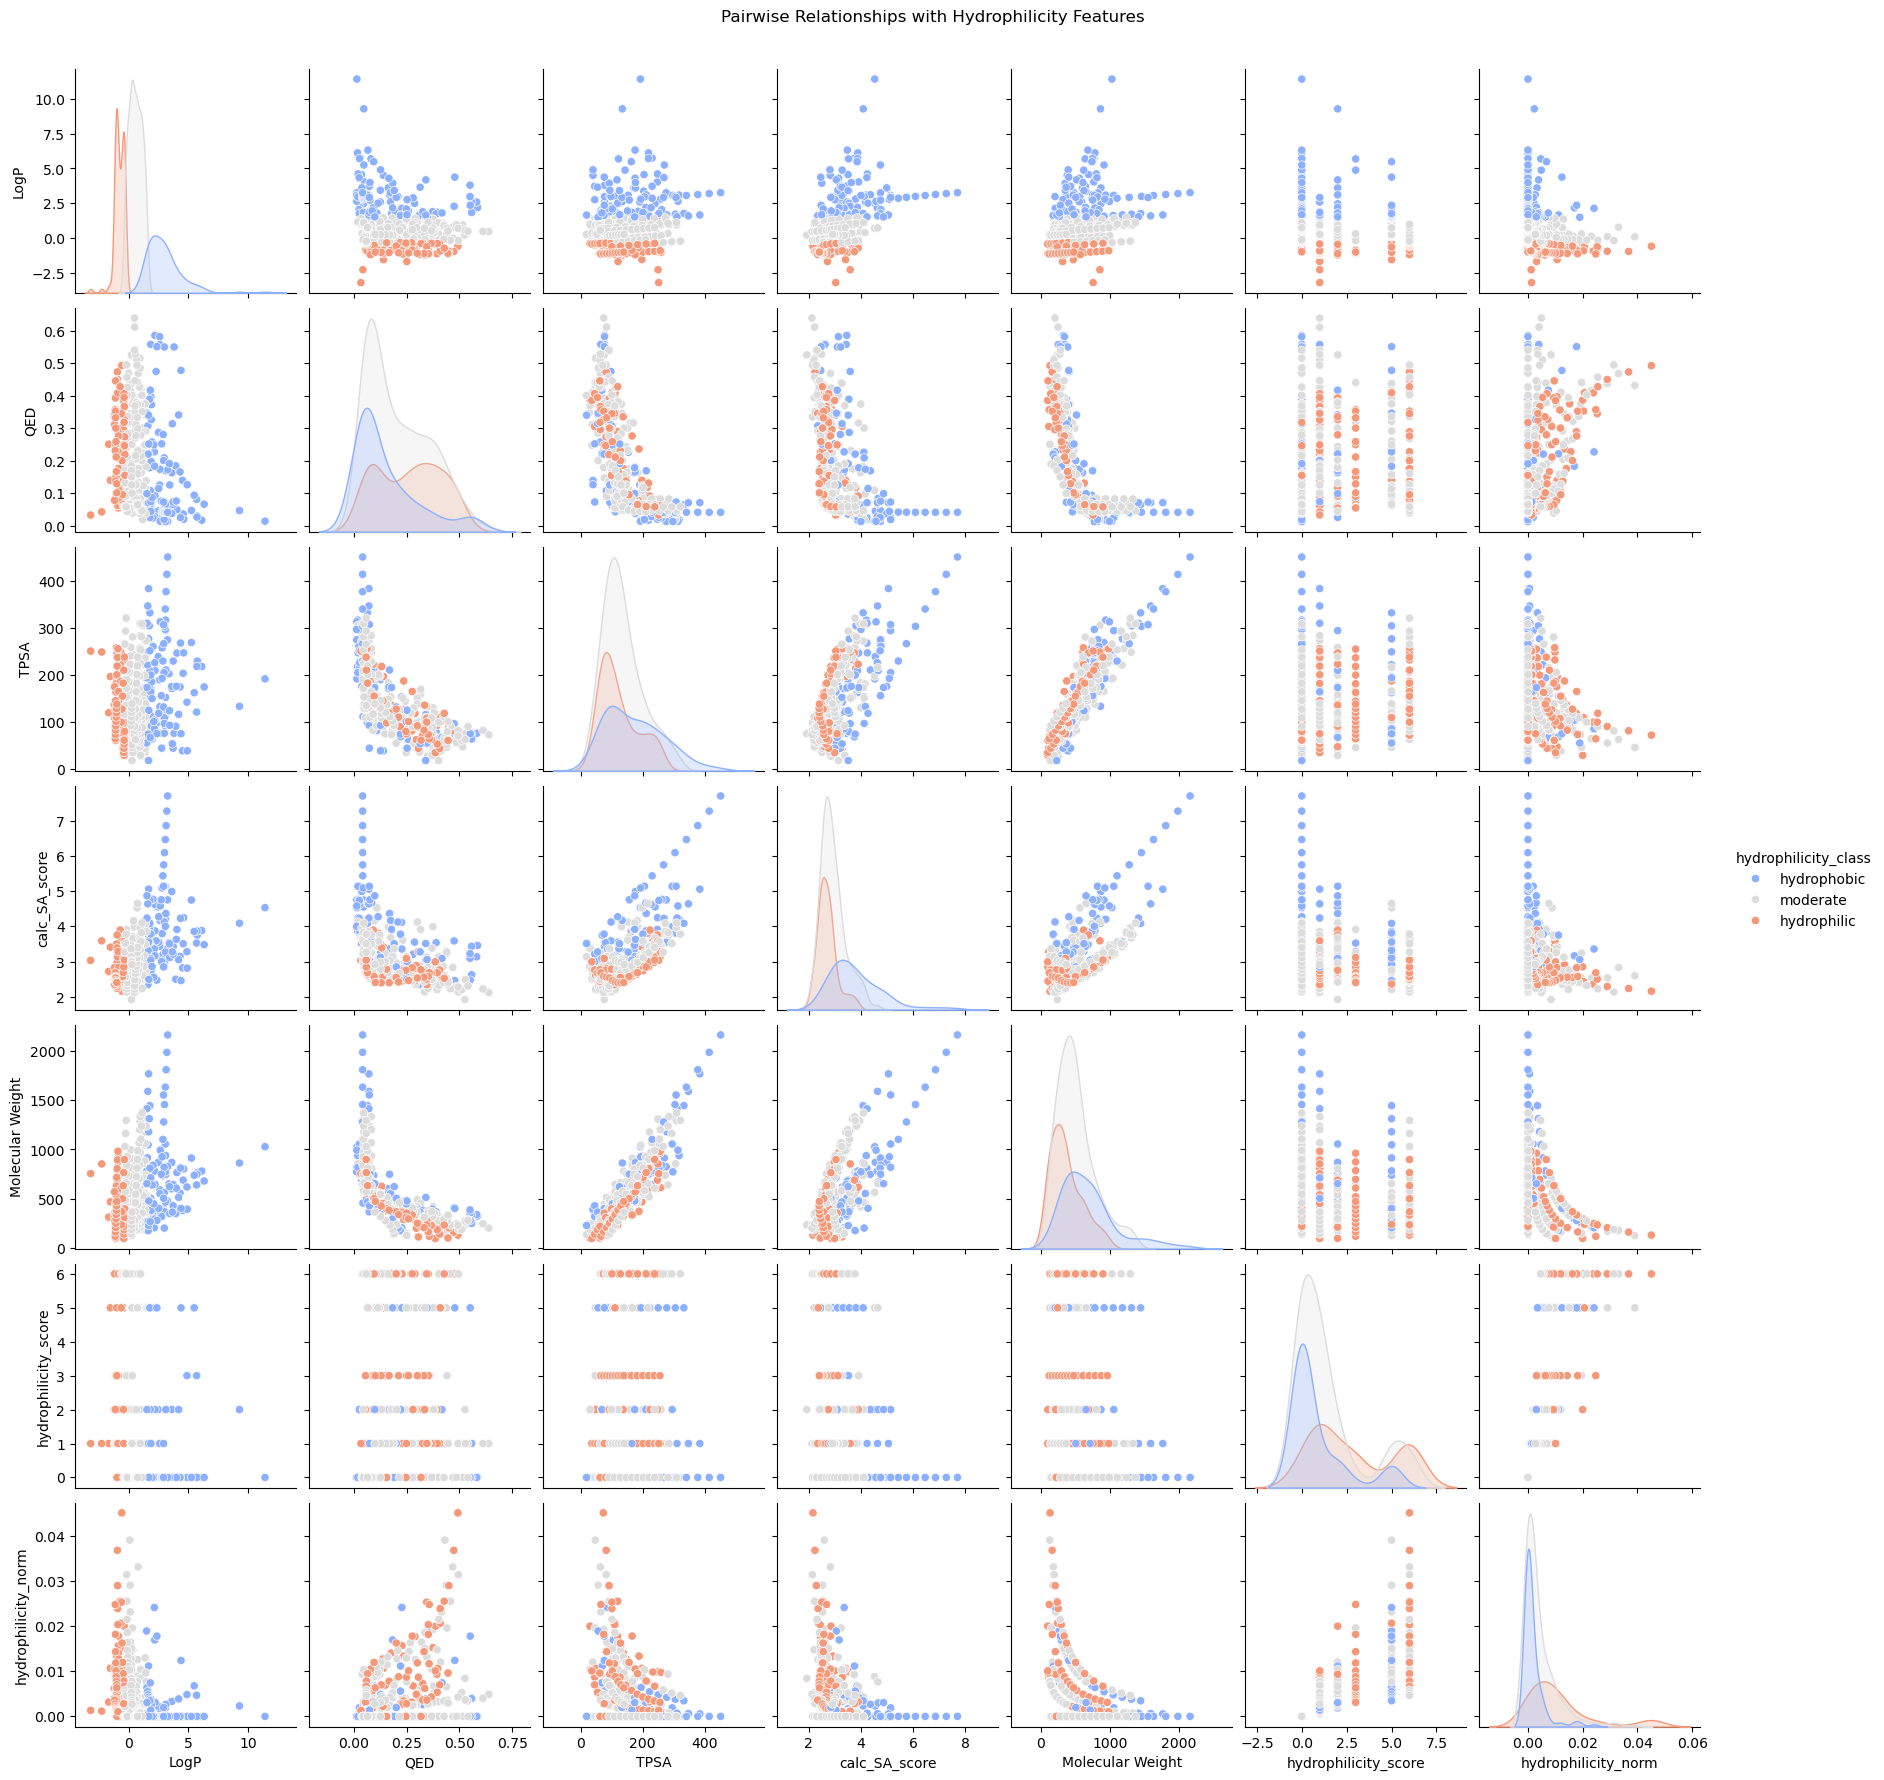

In [58]:
sns.pairplot(
    linker,
    vars=[
        'LogP', 'QED', 'TPSA', 'calc_SA_score',
        'Molecular Weight', 'hydrophilicity_score', 'hydrophilicity_norm'
    ],
    hue='hydrophilicity_class',       # color by hydrophilic/hydrophobic/moderate
    palette='coolwarm',
    diag_kind='kde'
)
plt.suptitle('Pairwise Relationships with Hydrophilicity Features', y=1.02)
plt.show()